In [161]:
# import packages
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [162]:
# setup traitors data frame
traitors = pd.read_csv('CelebrityTraitors26.csv')
traitors['Name'] = traitors['Name'].str.strip()

repeat_times = 9

traitors_ext = traitors.loc[np.repeat(traitors.index, repeat_times)].reset_index(drop=True)

start = 1
end = 22

traitors_ext['Episode'] = np.tile(range(1, 10), 21)
traitors_ext['y'] = np.repeat(range(start, end), repeat_times)

traitors_ext

# # setup predictions data
predictions = pd.read_csv('predictions.csv')
predictions['Name'] = predictions['Name'].str.strip()

ep_cols = [c for c in predictions.columns if c.startswith('Ep')]
status_long = predictions.melt(id_vars=['Name', 'Eliminated_Episode'], 
                               value_vars=ep_cols,
                               var_name='Episode',
                               value_name='Status')

status_long['Episode'] = status_long['Episode'].str.replace('Ep', '').astype(int)
status_long['Status'] = status_long['Status'].fillna('Pending')

elim_ep = status_long['Eliminated_Episode']
status_long.loc[elim_ep.notna() * (status_long['Episode'] >= elim_ep), 'Status'] = 'Eliminated'

traitors_ext = traitors_ext.merge(
    status_long[['Name', 'Episode', 'Status']], on=['Name', 'Episode'],
    how='left'
)

traitors_ext['Status'] = traitors_ext['Status'].fillna('Pending')

traitors_ext

,Name,Background,Episode,y,Status
0,Amol Rajan,Journalist and Broadcaster,1,1,Correct
1,Amol Rajan,Journalist and Broadcaster,2,1,Pending
2,Amol Rajan,Journalist and Broadcaster,3,1,Pending
3,Amol Rajan,Journalist and Broadcaster,4,1,Pending
4,Amol Rajan,Journalist and Broadcaster,5,1,Pending
...,...,...,...,...,...
184,Sharon Rooney,Actor,5,21,Pending
185,Sharon Rooney,Actor,6,21,Pending
186,Sharon Rooney,Actor,7,21,Pending
187,Sharon Rooney,Actor,8,21,Pending


In [163]:
predictions['Surname'] = predictions['Name'].str.strip().str.split().str[-1]

still_in = predictions[predictions['Eliminated_Episode'].isna()].sort_values('Surname')
eliminated = predictions[predictions['Eliminated_Episode'].notna()].sort_values('Eliminated_Episode', ascending=False)

order = pd.concat([still_in, eliminated])['Name'].tolist()

order_rank = {name: i + 1 for i, name in enumerate(order)}
traitors_ext['y'] = traitors_ext['Name'].map(order_rank)

In [164]:
status_style = {
    'Pending': {'facecolor': 'none', 'edgecolor': '#f57d07'},
    'Correct': {'facecolor': '#2ecc71', 'edgecolor': 'none'},
    'Wrong': {'facecolor': '#E8AEB7', 'edgecolor': 'none'},
    'Eliminated': {'facecolor': '#7F7B82', 'edgecolor': 'none'}
}

fill_colors = traitors_ext['Status'].map(lambda s: status_style[s]['facecolor']).tolist()
edge_colors = traitors_ext['Status'].map(lambda s: status_style[s]['edgecolor']).tolist()

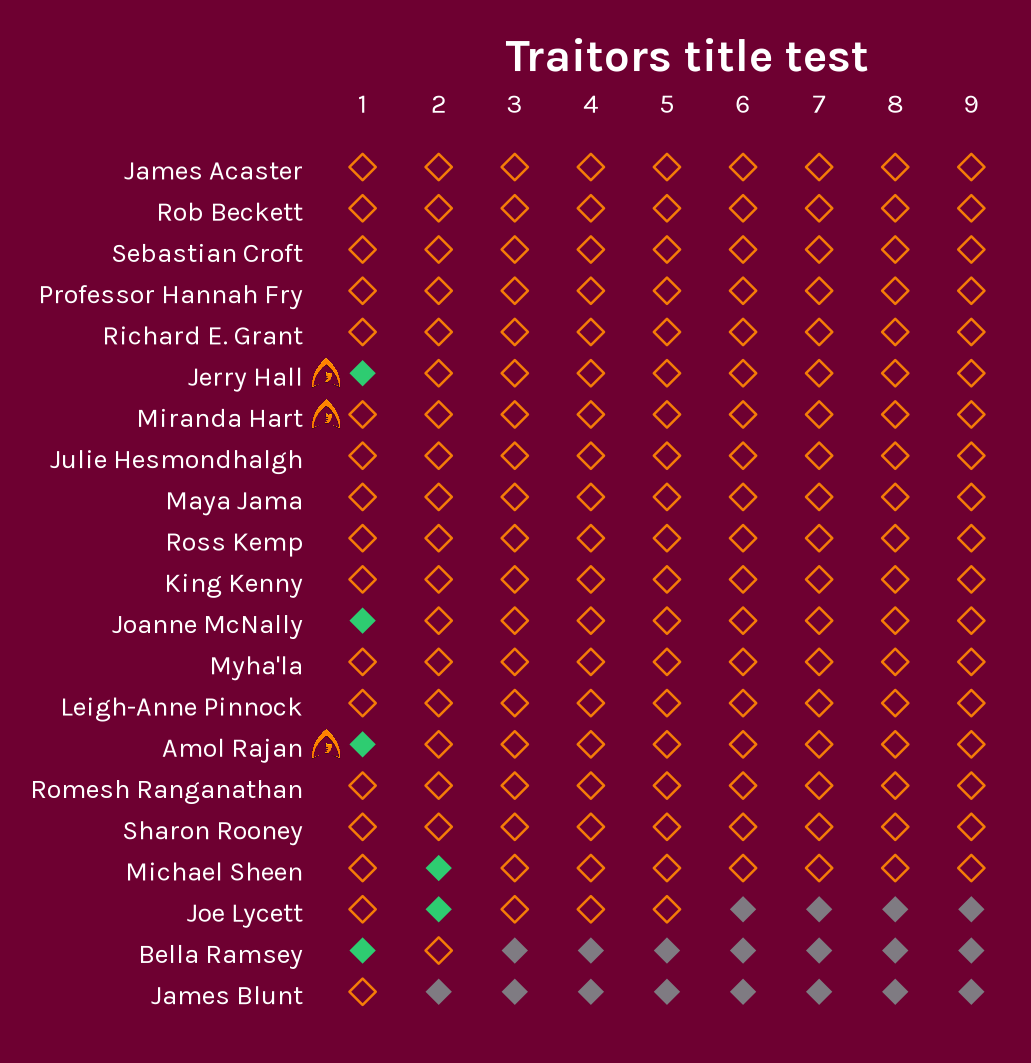

In [170]:
# colours
background = '#6e0031'

# set typeface properties
title_font = {
    'color': '#FFFFFF',
    'fontname': 'Karla',
    'weight': 'bold',
    'fontsize': 11
              }

subtitle_font = {
    'fontname': 'Inter Tight',
    'fontsize': 9
              }

source_font = {
    'fontname': 'Inter Tight',
    'fontsize': 5
              }

# create copy
title = 'Traitors title test'


# set up explicit dimensions
dpi = 300
width_px, height_px = 1080, 1080
figsize = (width_px / dpi, height_px / dpi)

# create plot
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
fig.subplots_adjust(left=0.34, right=0.96, top=0.90, bottom=0.06)


plt.scatter('Episode','y', data=traitors_ext, marker='D', s=20, edgecolors=edge_colors, facecolors=fill_colors, linewidths=0.6)

# aesthetics
fig.set_facecolor(background)
ax.patch.set_facecolor(background)

# titles
fig.text(0.5, 0.94, title, ha='left', va='bottom', **title_font)

# axes settings
plt.setp(ax.get_yticklabels(), fontname='Karla', size=6.5, color='#FFFFFF')


xtick_style = dict(fontname='Karla', size=6.5, color='#FFFFFF')
plt.setp(ax.get_xticklabels(), **xtick_style)
plt.setp([t.label2 for t in ax.xaxis.get_major_ticks()], **xtick_style)

ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False)
plt.tick_params(axis='x', which='both', bottom=False, top=False, pad=-2, labeltop=True, labelbottom=False)

# remove plot boders
for pos in ['right', 'top', 'bottom', 'left']:
    plt.gca().spines[pos].set_visible(False)

ax.set_yticks(ticks=range(1, 22), labels=order)
ax.set_xticks(ticks=range(1,10))
ax.invert_yaxis()


icon_map = {
    'Amol Rajan': 'images/traitorsIcon.png',
    'Jerry Hall': 'images/traitorsIcon.png',
    'Miranda Hart': 'images/traitorsIcon.png'
}

for name, ypos in zip(order, range(1,22)):
    icon_path = icon_map.get(name)
    if icon_path:
        img = plt.imread(icon_path)
        imagebox = OffsetImage(img, zoom=0.01)
        ab = AnnotationBbox(
            imagebox, (0, ypos),
            xycoords=ax.get_yaxis_transform(),
            box_alignment=(1, 0.5),
            xybox=(4,0), boxcoords='offset points',
            frameon=False, annotation_clip=False
        )
        ax.add_artist(ab)

# save final plot
plt.savefig("images/traitorstest.png", dpi=dpi, facecolor=fig.get_facecolor())

plt.show()
